## Notebook para visualizar el espacio latente de distintos modelos

Usando fashion como dataset



/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


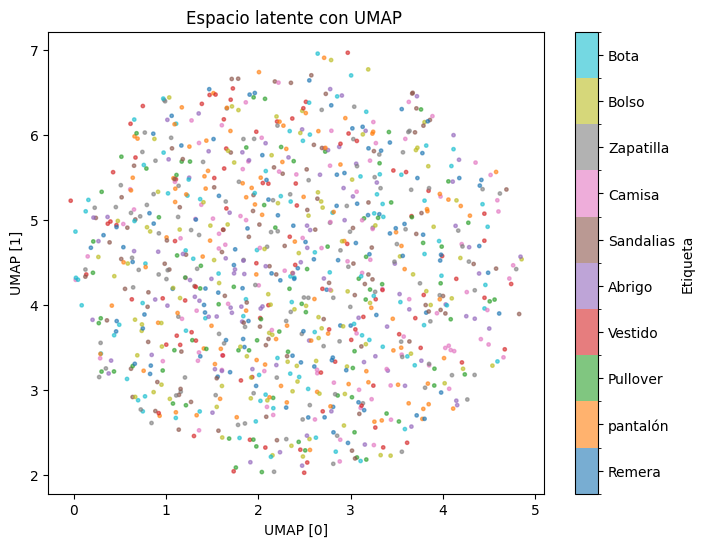

In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import Loader

import project.visualizations.visualizations as vis
import tensorflow as tf

DATASET="fashion" # mnist o fashion
N_POINTS=1000 # Cantidad de puntos a visualizar


#Puede ser cualquiera de los modelos entrenados
cvae = Loader.cvae(lat=64, inter=128, dataset=DATASET)

data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)


x_test = data["x_test"]
y_test = data["y_test"]
labels = data["labels"]

test_dataset = tf.data.Dataset.from_tensor_slices(((x_test, y_test), x_test))

print(cvae.name)

vis.latent_space_umap(cvae, test_dataset, n_points=N_POINTS,label_names=labels, title= cvae.name)



Usando fashion como dataset
inter128_lat2


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


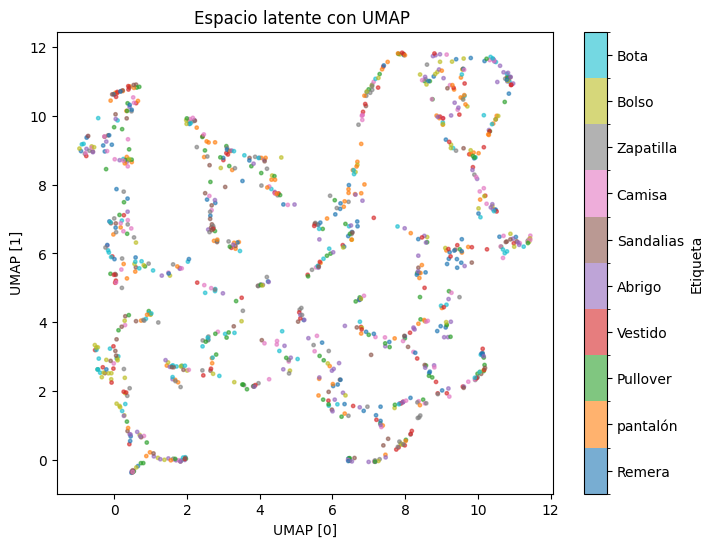

inter128_lat64


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


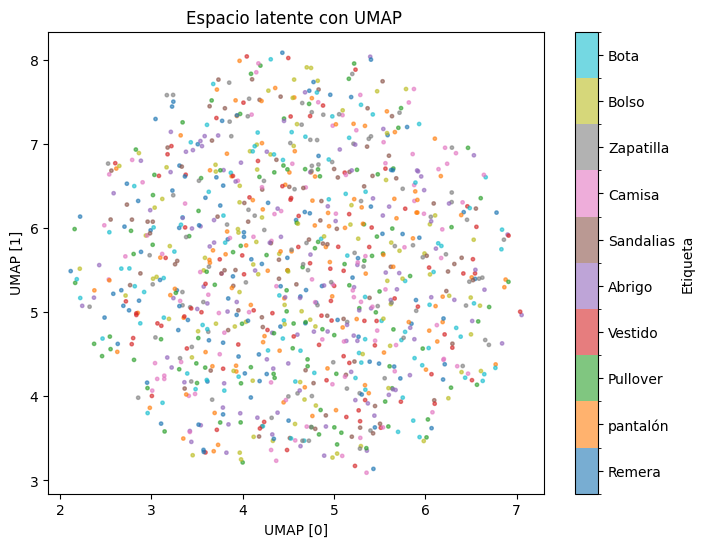

inter256_lat64


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


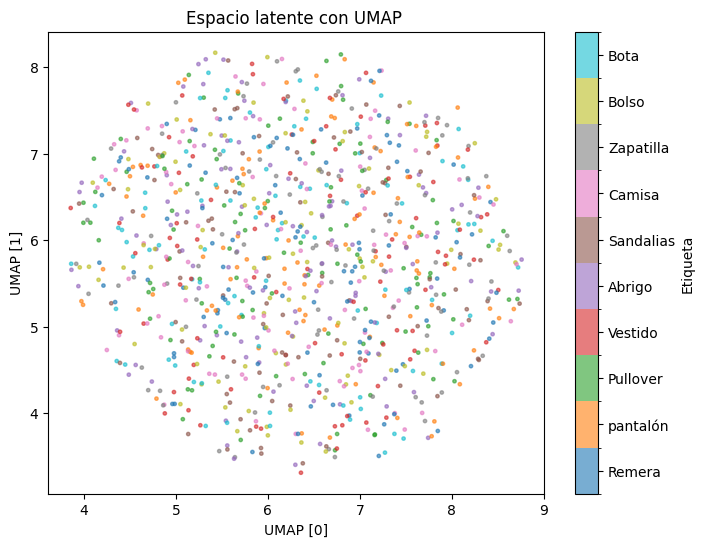

inter256_lat128


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


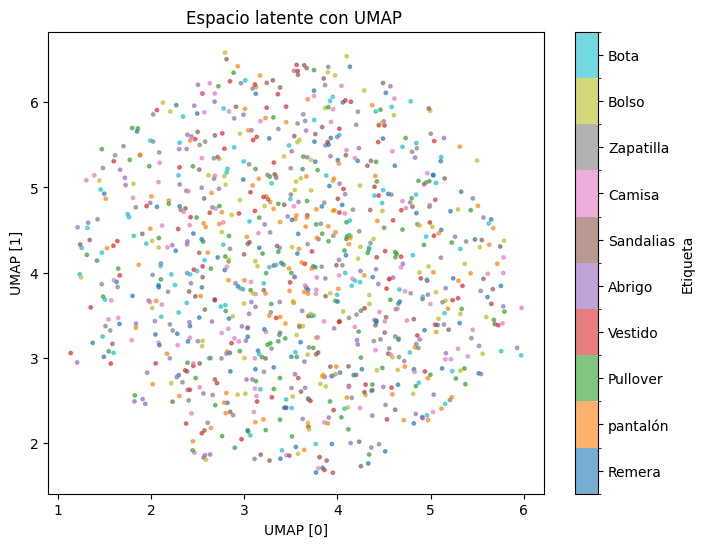

inter512_lat128


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


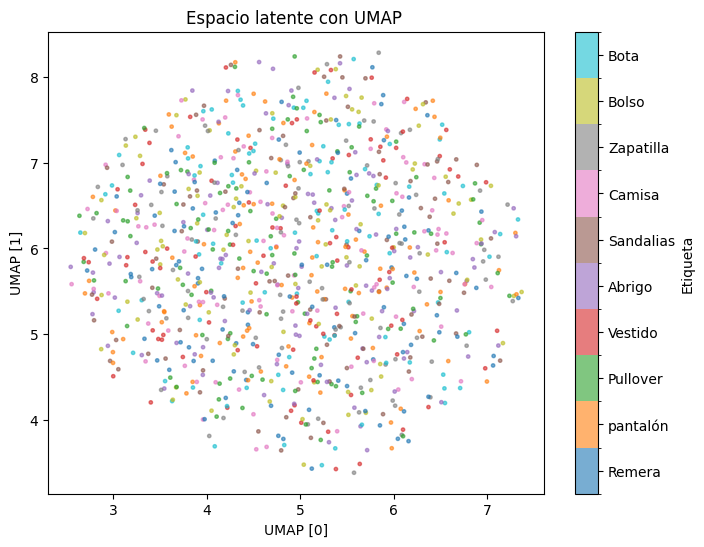

inter512_lat256


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


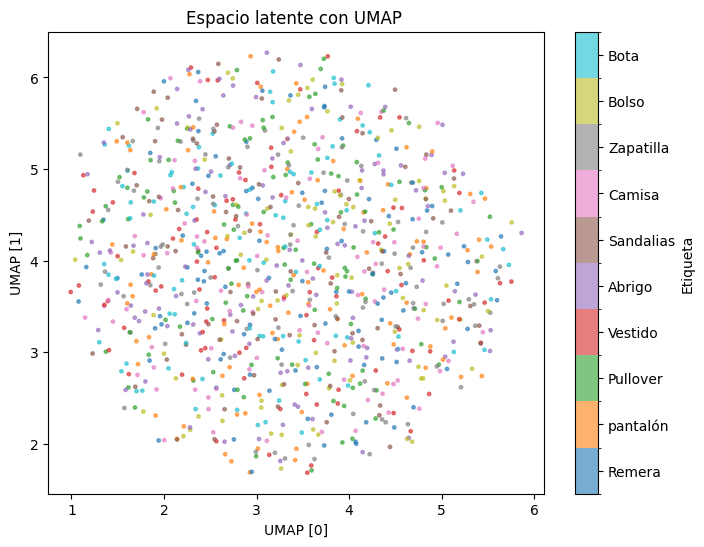

inter784_lat784


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


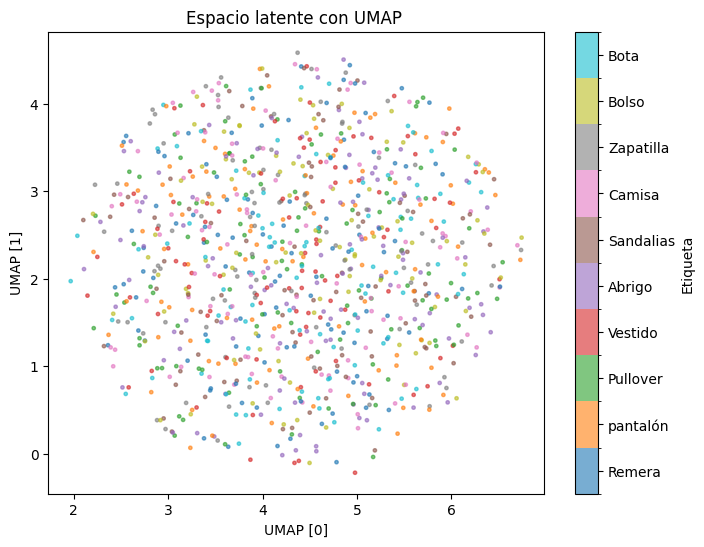

In [45]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader

import project.visualizations.visualizations as vis
import tensorflow as tf

MODELS = [ # Modelos usados para comparar
    {"inter": 128, "lat": 2},
    {"inter": 128, "lat": 64},
    {"inter": 256, "lat": 64},
   {"inter": 256, "lat": 128},
   {"inter": 512, "lat": 128},
   {"inter": 512, "lat": 256},
   {"inter": 784, "lat": 784},
]

DATASET="fashion" # mnist o fashion
N_POINTS=1000 # Cantidad de puntos a visualizar


#Puede ser cualquiera de los modelos entrenados

data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)


x_test = data["x_test"]
y_test = data["y_test"]
labels = data["labels"]

test_dataset = tf.data.Dataset.from_tensor_slices(((x_test, y_test), x_test))


for model in MODELS:

    inter = model["inter"]
    lat = model["lat"]

    cvae = Loader.cvae(lat=lat, inter=inter, dataset=DATASET)

    print(f"inter{inter}_lat{lat}")


    vis.latent_space_umap(cvae, test_dataset, n_points=N_POINTS,label_names=labels, title= cvae.name)


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_435251/2094062912.py:56: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  sc = plt.scatter(


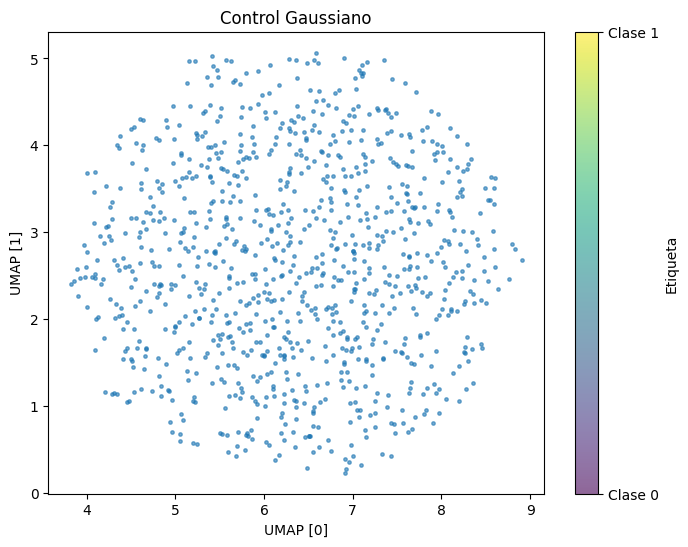

In [58]:
def umap_gaussian_control(
    n_points=2000,
    dim=10,
    n_classes=5,
    save_path=None,
    title="Control Gaussiano",
    label_names=None
):
    import numpy as np
    import matplotlib.pyplot as plt
    import umap
    from matplotlib.colors import ListedColormap, BoundaryNorm

    # -----------------------------
    # Generar datos gaussianos
    # -----------------------------
    np.random.seed(42)

    z_all = []
    y_all = []

    cov = np.eye(dim)

    samples = np.random.multivariate_normal(
        np.zeros(dim), cov, size=n_points)

    z_all.append(samples)
    y_all.append(labels)

    z_all = np.concatenate(z_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)

    # -----------------------------
    # Label names
    # -----------------------------
    if label_names is None:
        label_names = [f"Clase {i}" for i in range(n_classes)]

    # -----------------------------
    # UMAP
    # -----------------------------
    reducer = umap.UMAP(n_components=2, random_state=42)
    z_umap = reducer.fit_transform(z_all)

    # -----------------------------
    # Colormap
    # -----------------------------
    cmap = ListedColormap(plt.cm.tab10.colors[:n_classes])
    boundaries = np.arange(-0.5, n_classes, 1)
    norm = BoundaryNorm(boundaries, cmap.N)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        z_umap[:, 0],
        z_umap[:, 1],
        cmap=cmap,
        norm=norm,
        s=6,
        alpha=0.6
    )

    cbar = plt.colorbar(sc, ticks=np.arange(n_classes))
    cbar.set_ticklabels(label_names)
    cbar.set_label("Etiqueta")

    plt.xlabel("UMAP [0]")
    plt.ylabel("UMAP [1]")
    plt.title(title)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

umap_gaussian_control(
    n_points=1000,
    dim=64,
    n_classes=10,
    save_path=None,
    title="Control Gaussiano")